## Granger Causality Example

Coded by: Michelle Maclennan (ATOC5860 Fall 2020), with review/updates by Erin Guderian/Jen Kay in Spring 2022 (University of Colorado)

Last updated: February 16, 2022

In [2]:
# Load libraries 
%matplotlib inline  
# this enables plotting within notebook

import matplotlib   # library for plotting
import matplotlib.pyplot as plt #  later you will type plt.$COMMAND
import numpy as np   # basic math library  you will type np.$STUFF  e.g., np.cos(1)
import pandas as pd  # library for data analysis for text files (everything but netcdf files)
import scipy
import scipy.stats as stats # imports stats functions https://docs.scipy.org/doc/scipy/reference/stats.html 
from scipy import signal
import xarray as xr
from sklearn import linear_model
from sklearn import metrics

Here, we select two variables (variable X, variable Y) you are using in your research that you think might be related.  We will ask: can you use variable X to predict variable Y using linear regression?

From Turner et al., 2012 (https://rmets.onlinelibrary.wiley.com/doi/full/10.1002/joc.3558), the phase of the Southern annular mode (SAM) influences the depth of the Amundsen Sea Low (ASL).   Specifically, when the SAM index is negative (positive), there are positive (negative) ASL sea level pressure anomalies. In other words, we anticipate a inverse relationship between the monthly mean pressure of the ASL and the month SAM index. # Marshall SAM index is the independent variable (X), and the ASL is the dependent variable (Y).

In [3]:
# Read in the data

# Variable A: Indices of the Southern Annular Mode
filename = "Marshall_SAM_monthly_inds.csv"
data=pd.read_csv(filename,sep=',',header=3)
year_A = np.array(data)[22:-2,0] # Start in year 1979, end Dec 2017
# Organize data from monthly columns to one long time series (to match Variable B)
SAM_index = np.empty(())
for i in range(len(year_A)):
    SAM_index = np.append(SAM_index,np.array(data)[22+i,1:13])
SAM_index = SAM_index[1:]

# Variable B: Central Pressure of the Amundsen Sea Low
filename = "Hosking_ASL_monthly_inds.csv"
data=pd.read_csv(filename,sep=',',header=10) #
year_B = np.array(data)[:-3,0] # Time series from Jan 1979 - Dec 2017
month_B = np.array(data)[:-3,1]
sector_pressure = np.array(data)[:-3,2]
central_pressure = np.array(data)[:-3,3]
#relative_central_pressure = central_pressure - sector_pressure
print(np.shape(SAM_index))
print(np.shape(central_pressure))

(468,)
(468,)


Next, we'll plot the data as a line plot (plot 1) and as a scatter plot (plot 2).  
Look at your data

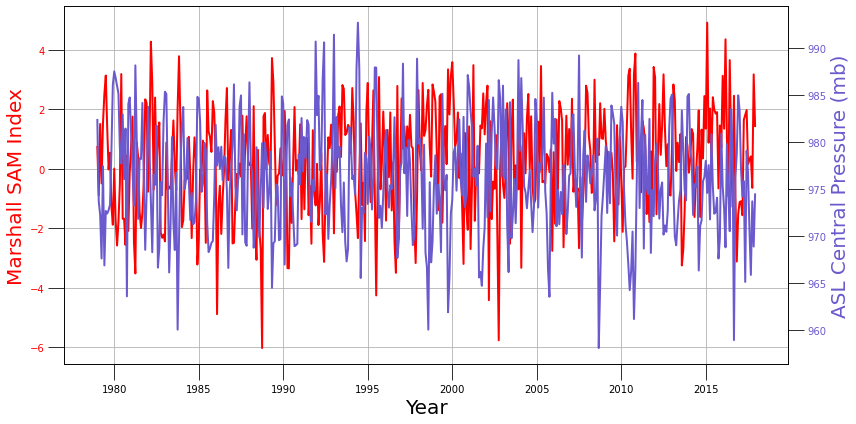

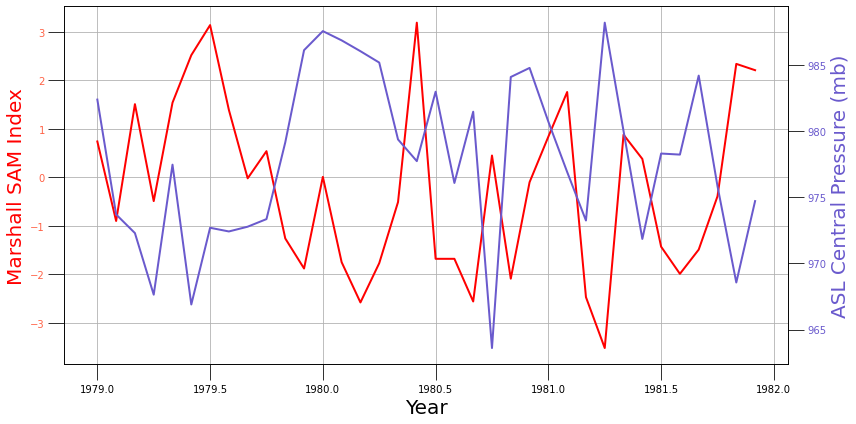

In [4]:
# Plot 1: Time series of raw data 
time = np.linspace(0,len(SAM_index)-1,len(SAM_index))/12 + 1979
fig, ax1 = plt.subplots(figsize=(12,6))
#color = 'tab:purple'
ax1.set_xlabel('Year',fontsize=20)
ax1.set_ylabel('Marshall SAM Index', color="red",fontsize=20)
ax1.plot(time,SAM_index, color="red",linewidth=2)
ax1.tick_params(axis='y',labelcolor="red",size=16)
ax1.tick_params(axis='x',labelcolor='black',size=16)
ax1.grid()
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
#color = 'tab:blue'
ax2.set_ylabel('ASL Central Pressure (mb)',color="slateblue",fontsize=20)  # we already handled the x-label with ax1
ax2.plot(time,central_pressure,color="slateblue",linewidth=2)
ax2.tick_params(axis='y',labelcolor="slateblue",size=16)
#ax2.grid()
fig.tight_layout()  # otherwise the right y-label is slightly clipped

# Zoom in to a shorter section - 3 years - to better visualize short-term variation 
time = np.linspace(0,len(SAM_index)-1,len(SAM_index))/12 + 1979
fig, ax1 = plt.subplots(figsize=(12,6))
#color = 'tab:purple'
ax1.set_xlabel('Year',fontsize=20)
ax1.set_ylabel('Marshall SAM Index', color="red",fontsize=20)
ax1.plot(time[0:36],SAM_index[0:36], color="red",linewidth=2)
ax1.tick_params(axis='y',labelcolor="tomato",size=16)
ax1.tick_params(axis='x',labelcolor='black',size=16)
ax1.grid()
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
#color = 'tab:blue'
ax2.set_ylabel('ASL Central Pressure (mb)',color="slateblue",fontsize=20)  # we already handled the x-label with ax1
ax2.plot(time[0:36],central_pressure[0:36],color="slateblue",linewidth=2)
ax2.tick_params(axis='y',labelcolor="slateblue",size=16)
#ax2.grid()
fig.tight_layout()  # otherwise the right y-label is slightly clipped

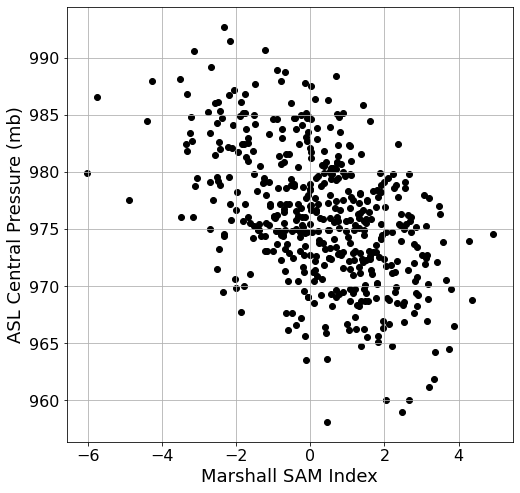

In [5]:
# Plot 2: Scatter plot
# The Marshall SAM index will be set to the x-axis as the independent variable, and the 
    # ASL will be treated as the dependent variable on the y-axis

plt.figure(figsize=(8,8));
plt.scatter(SAM_index,central_pressure,color='k');
plt.grid();
plt.xticks(fontsize=16);
plt.yticks(fontsize=16);
plt.xlabel("Marshall SAM Index",fontsize=18);
plt.ylabel("ASL Central Pressure (mb)",fontsize=18);

Next - we'll standardize the data (i.e., subtract the mean and divide by the standard deviation). After this, both variables have a mean of 0 and a standard deviation of 1. We will also detrend.

In [6]:
# Detrend data (subtract linear trend)
SAM_index_detrended = scipy.signal.detrend(SAM_index,type='linear')
central_pressure_detrended = scipy.signal.detrend(central_pressure,type='linear')

In [7]:
# Standardize by subtracting the mean and dividing by the standard deviation
SAM_index_detrended_standardized = (SAM_index_detrended - np.mean(SAM_index_detrended))/np.std(SAM_index_detrended)
central_pressure_detrended_standardized = (central_pressure_detrended - np.mean(central_pressure_detrended))/np.std(central_pressure_detrended)

# Check to make sure it worked - print mean and std
print("Detrended SAM Index: mean = ",np.round(np.mean(SAM_index_detrended_standardized),4)," and std = ",np.round(np.std(SAM_index_detrended_standardized),4))
print("Detrended Central Pressure: mean = ",np.round(np.mean(central_pressure_detrended_standardized),4)," and std = ",np.round(np.std(central_pressure_detrended_standardized),4))

Detrended SAM Index: mean =  0.0  and std =  1.0
Detrended Central Pressure: mean =  -0.0  and std =  1.0


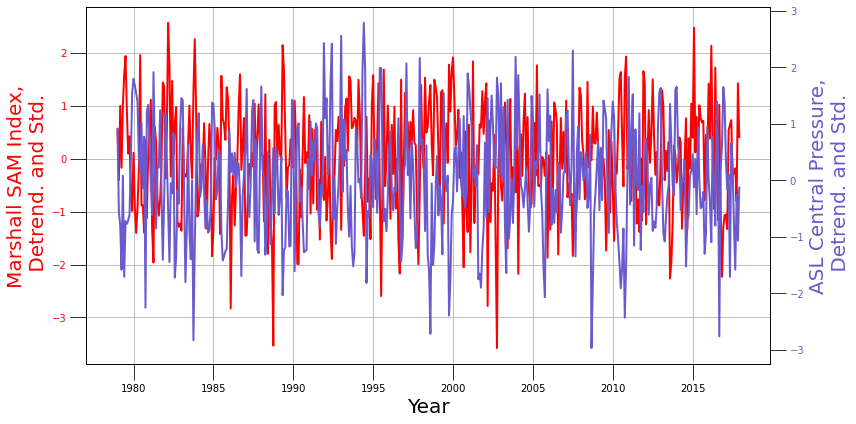

In [8]:
# Plot 1: Time series of raw data - this time detrended and standardized 

time = np.linspace(0,len(SAM_index)-1,len(SAM_index))/12 + 1979
fig, ax1 = plt.subplots(figsize=(12,6))
#color = 'tab:purple'
ax1.set_xlabel('Year',fontsize=20)
ax1.set_ylabel('Marshall SAM Index,\n Detrend. and Std.', color="red",fontsize=20)
ax1.plot(time,SAM_index_detrended_standardized, color="red",linewidth=2)
ax1.tick_params(axis='y',labelcolor="red",size=16)
ax1.tick_params(axis='x',labelcolor='black',size=16)
ax1.grid()
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
#color = 'tab:blue'
ax2.set_ylabel('ASL Central Pressure,\n Detrend. and Std.',color="slateblue",fontsize=20)  # we already handled the x-label with ax1
ax2.plot(time,central_pressure_detrended_standardized,color="slateblue",linewidth=2)
ax2.tick_params(axis='y',labelcolor="slateblue",size=16)
#ax2.grid()
fig.tight_layout()  # otherwise the right y-label is slightly clipped

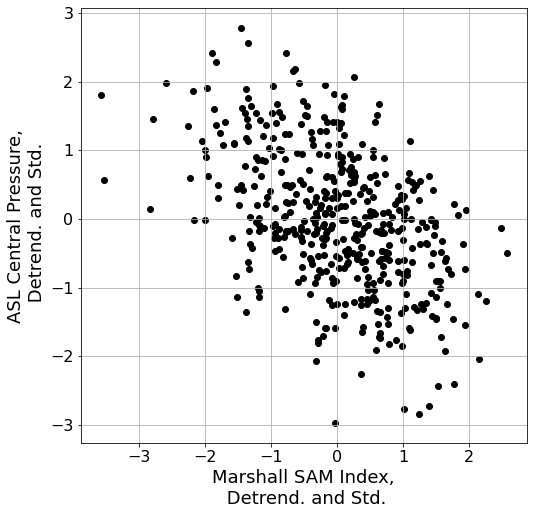

In [9]:
# Plot 2: Scatter plot - detrended and standardized 
# The Marshall SAM index will be set to the x-axis as the independent variable, and the 
    # ASL will be treated as the dependent variable on the y-axis

plt.figure(figsize=(8,8));
plt.scatter(SAM_index_detrended_standardized,central_pressure_detrended_standardized,color='k');
plt.grid();
plt.xticks(fontsize=16);
plt.yticks(fontsize=16);
plt.xlabel('Marshall SAM Index,\n Detrend. and Std.',fontsize=18);
plt.ylabel('ASL Central Pressure,\n Detrend. and Std.',fontsize=18);

#### Calculate the autocorrelation and estimate the number of independent samples for both of your variables

In [10]:
# SAM Index

# Estimate lag-1 autocorrelation
mean = np.mean(SAM_index_detrended_standardized)
sigma = np.std(SAM_index_detrended_standardized)
N = len(SAM_index_detrended_standardized)
lag=1
t1_m=SAM_index_detrended_standardized[0:-1*lag]-mean
t2_m=SAM_index_detrended_standardized[lag:]-mean

# Method #1: calculate the autocorrelation using numpy correlate lagN
AR1_np=np.correlate(t1_m,t2_m,mode='valid')/(N-lag)/(sigma**2)
print('SAM Index: np.correlate AR1:',round(AR1_np[0],5))

# Method #2 - direct calculation: calculate the autocorrelation using numpy dot
    # (https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.dot.html)
AR1=np.dot(t1_m,t2_m)/(N-lag)/sigma**2 ## Barnes Chapter 2 Eq. 68 divided by the variance
print('SAM Index: direct calculation AR1:',round(AR1,5))

# Calculate effective sample size
Nstar_wilks_SAM=round(((1-AR1)/(1+AR1))*N) ## Barnes Chapter 2 eq. 88
Nstar_leith_SAM=round((-0.5*np.log(AR1))*N) ## Barnes Chapter 2 eq. 90
print('Sample Size:',N)
print('Effective Sample Size Wilks (#independent samples):',Nstar_wilks_SAM)
print('Effective Sample Size Leith (#independent samples):',Nstar_leith_SAM)

SAM Index: np.correlate AR1: 0.19504
SAM Index: direct calculation AR1: 0.19504
Sample Size: 468
Effective Sample Size Wilks (#independent samples): 315
Effective Sample Size Leith (#independent samples): 382


In [11]:
# ASL Central Pressure

# Estimate lag-1 autocorrelation
mean = np.mean(central_pressure_detrended_standardized)
sigma = np.std(central_pressure_detrended_standardized)
N = len(central_pressure_detrended_standardized)
lag=1
t1_m=central_pressure_detrended_standardized[0:-1*lag]-mean
t2_m=central_pressure_detrended_standardized[lag:]-mean

# Method #1: calculate the autocorrelation using numpy correlate lagN
AR1_np=np.correlate(t1_m,t2_m,mode='valid')/(N-lag)/(sigma**2)
print('ASL Central Pressure: np.correlate AR1:',round(AR1_np[0],5))

# Method #2 - direct calculation: calculate the autocorrelation using numpy dot
    # (https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.dot.html)
AR1=np.dot(t1_m,t2_m)/(N-lag)/sigma**2 ## Barnes Chapter 2 Eq. 68 divided by the variance
print('ASL Central Pressure: direct calculation AR1:',round(AR1,5))

# Calculate effective sample size
Nstar_wilks_ASL=round(((1-AR1)/(1+AR1))*N) ## Barnes Chapter 2 eq. 88
Nstar_leith_ASL=round((-0.5*np.log(AR1))*N) ## Barnes Chapter 2 eq. 90
print('Sample Size:',N)
print('Effective Sample Size Wilks (#independent samples):',Nstar_wilks_ASL)
print('Effective Sample Size Leith (#independent samples):',Nstar_leith_ASL)

ASL Central Pressure: np.correlate AR1: 0.31853
ASL Central Pressure: direct calculation AR1: 0.31853
Sample Size: 468
Effective Sample Size Wilks (#independent samples): 242
Effective Sample Size Leith (#independent samples): 268


#### Complete a regression between two variables. Assess the statistical significance taking into account the number of independent samples. Place confidence intervals on your regression coefficient. Provide any other statistical results that are helping you interpret your data. Plot the results

In [12]:
# Regression 
slope, intercept, r_value, p_value, std_err = stats.linregress(SAM_index_detrended_standardized,central_pressure_detrended_standardized)
print("Slope (regression coefficient): ",np.round(slope,3))
print("Y-intercept: ",np.round(intercept,3))
print("Correlation coefficient (r): ",np.round(r_value,3))
print("Percent variance explained (r square): ",np.round((r_value**2)*100,2), "%")

Slope (regression coefficient):  -0.473
Y-intercept:  0.0
Correlation coefficient (r):  -0.473
Percent variance explained (r square):  22.4 %


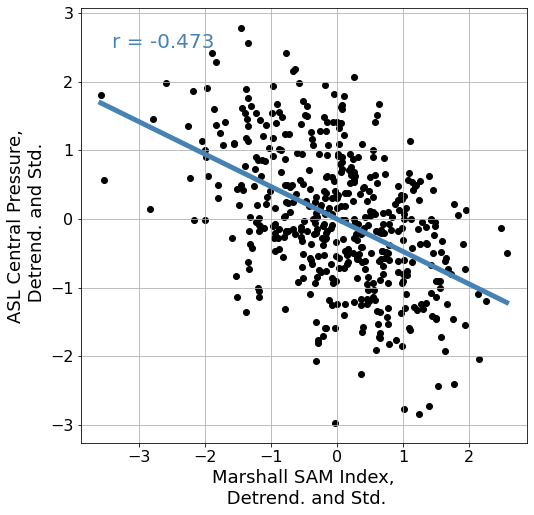

In [12]:
plt.figure(figsize=(8,8));
plt.scatter(SAM_index_detrended_standardized,central_pressure_detrended_standardized,color='k')
plt.plot(np.linspace(np.min(SAM_index_detrended_standardized),np.max(SAM_index_detrended_standardized),len(SAM_index_detrended_standardized)),np.linspace(np.min(SAM_index_detrended_standardized),np.max(SAM_index_detrended_standardized),len(SAM_index_detrended_standardized))*slope + intercept,color='steelblue',linewidth=5);
plt.grid();
plt.xticks(fontsize=16);
plt.yticks(fontsize=16);
plt.text(-3.4,2.5,"r = -0.473",fontsize=20,color='steelblue');
plt.xlabel('Marshall SAM Index,\n Detrend. and Std.',fontsize=18);
plt.ylabel('ASL Central Pressure,\n Detrend. and Std.',fontsize=18);

In [41]:
# Statistical significance
N = min(Nstar_wilks_SAM,Nstar_wilks_ASL) # minimum effective sample size from the tests above, 242
#print("Sample size: N =",N)
print("Effective sample size: N =",N)

# Because we have N>30 samples and we assume 1 degree of freedom per year, we can use 
    # the Z statistical test with 95% confidence intervals
    # Null hypothesis: there a correlation between the SAM Index and the ASL central pressure 

# Use Fisher-Z to calculate Z, sigma_Z
Z=0.5*np.log((1+slope)/(1-slope))
sigma_Z=1/np.sqrt(N-3)
print('Z:',round(Z,2))
print('sigma_Z:',round(sigma_Z,2))

# Find 95% confidence intervals on the true correlation.
tstat95=stats.t.ppf(0.975,N-2)  ## two-sided 95%
min_Z_value=Z-tstat95*sigma_Z
max_Z_value=Z+tstat95*sigma_Z
min_r_value=np.tanh(min_Z_value)
max_r_value=np.tanh(max_Z_value)
print('r_value:',round(r_value,3))
print('min_r_value:',round(min_r_value,3))
print('max_r_value:',round(max_r_value,3))

print('We cannot reject null hypothesis; 95% confidence bounds exclude correlation=0')
print('Results are consistent with the null hypothesis that the SAM index is correlated with the ASL central pressure.')


Effective sample size: N = 242
Z: -0.39
sigma_Z: 0.06
r_value: -0.219
min_r_value: -0.48
max_r_value: -0.261
We cannot reject null hypothesis; 95% confidence bounds exclude correlation=0
Results are consistent with the null hypothesis that the SAM index is correlated with the ASL central pressure.


Slope (regression coefficient):  -0.376
Y-intercept:  -0.144
Correlation coefficient (r):  -0.219
Percent variance explained (r square):  4.8 %


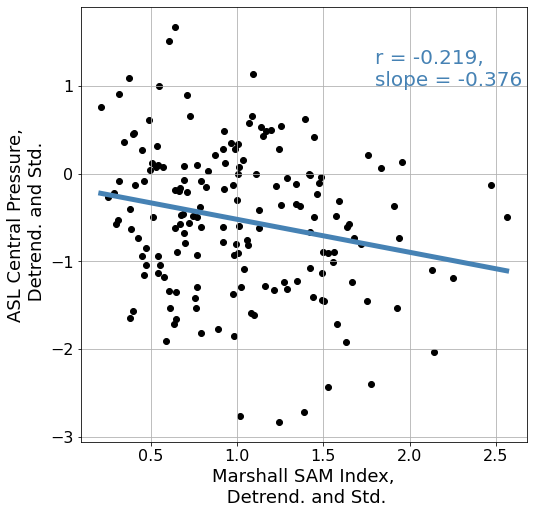

Effective sample size: N = 242
Z: -0.39
sigma_Z: 0.06
r_value: -0.219
min_r_value: -0.48
max_r_value: -0.261
We cannot reject null hypothesis; 95% confidence bounds exclude correlation=0
Results are consistent with the null hypothesis that the SAM index is correlated with the ASL central pressure.


In [42]:
# Regression for SAM > 1

# Regression 
slope, intercept, r_value, p_value, std_err = stats.linregress(SAM_index_detrended_standardized[SAM_index>1],central_pressure_detrended_standardized[SAM_index>1])
print("Slope (regression coefficient): ",np.round(slope,3))
print("Y-intercept: ",np.round(intercept,3))
print("Correlation coefficient (r): ",np.round(r_value,3))
print("Percent variance explained (r square): ",np.round((r_value**2)*100,2), "%")

plt.figure(figsize=(8,8))
plt.scatter(SAM_index_detrended_standardized[SAM_index>1],central_pressure_detrended_standardized[SAM_index>1],color='k')
plt.plot(np.linspace(np.min(SAM_index_detrended_standardized[SAM_index>1]),np.max(SAM_index_detrended_standardized[SAM_index>1]),len(SAM_index_detrended_standardized[SAM_index>1])),np.linspace(np.min(SAM_index_detrended_standardized[SAM_index>1]),np.max(SAM_index_detrended_standardized[SAM_index>1]),len(SAM_index_detrended_standardized[SAM_index>1]))*slope + intercept,color='steelblue',linewidth=5)
plt.grid()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.text(1.8,1,"r = -0.219,\nslope = -0.376",fontsize=20,color='steelblue')
plt.xlabel('Marshall SAM Index,\n Detrend. and Std.',fontsize=18)
plt.ylabel('ASL Central Pressure,\n Detrend. and Std.',fontsize=18)
plt.show()

# Statistical significance
N = min(Nstar_wilks_SAM,Nstar_wilks_ASL) # minimum effective sample size from the tests above, 242
#print("Sample size: N =",N)
print("Effective sample size: N =",N)

# Because we have N>30 samples and we assume 1 degree of freedom per year, we can use 
    # the Z statistical test with 95% confidence intervals
    # Null hypothesis: there a correlation between the SAM Index and the ASL central pressure 

# Use Fisher-Z to calculate Z, sigma_Z
Z=0.5*np.log((1+slope)/(1-slope))
sigma_Z=1/np.sqrt(N-3)
print('Z:',round(Z,2))
print('sigma_Z:',round(sigma_Z,2))

# Find 95% confidence intervals on the true correlation.
tstat95=stats.t.ppf(0.975,N-2)  ## two-sided 95%
min_Z_value=Z-tstat95*sigma_Z
max_Z_value=Z+tstat95*sigma_Z
min_r_value=np.tanh(min_Z_value)
max_r_value=np.tanh(max_Z_value)
print('r_value:',round(r_value,3))
print('min_r_value:',round(min_r_value,3))
print('max_r_value:',round(max_r_value,3))

print('We cannot reject null hypothesis; 95% confidence bounds exclude correlation=0')
print('Results are consistent with the null hypothesis that the SAM index is correlated with the ASL central pressure.')

Slope (regression coefficient):  -0.394
Y-intercept:  0.124
Correlation coefficient (r):  -0.238
Percent variance explained (r square):  5.69 %


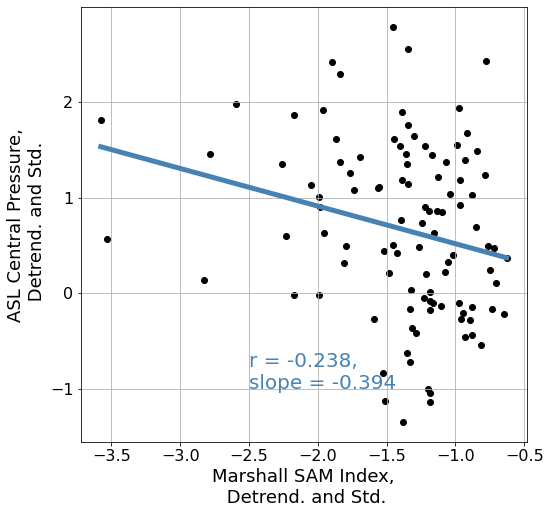

Effective sample size: N = 242
Z: -0.42
sigma_Z: 0.06
r_value: -0.238
min_r_value: -0.496
max_r_value: -0.281
We cannot reject null hypothesis; 95% confidence bounds exclude correlation=0
Results are consistent with the null hypothesis that the SAM index is correlated with the ASL central pressure.


In [15]:
# Regression for SAM < -1

# Regression 
slope, intercept, r_value, p_value, std_err = stats.linregress(SAM_index_detrended_standardized[SAM_index<-1],central_pressure_detrended_standardized[SAM_index<-1])
print("Slope (regression coefficient): ",np.round(slope,3))
print("Y-intercept: ",np.round(intercept,3))
print("Correlation coefficient (r): ",np.round(r_value,3))
print("Percent variance explained (r square): ",np.round((r_value**2)*100,2), "%")

plt.figure(figsize=(8,8))
plt.scatter(SAM_index_detrended_standardized[SAM_index<-1],central_pressure_detrended_standardized[SAM_index<-1],color='k')
plt.plot(np.linspace(np.min(SAM_index_detrended_standardized[SAM_index<-1]),np.max(SAM_index_detrended_standardized[SAM_index<-1]),len(SAM_index_detrended_standardized[SAM_index<-1])),np.linspace(np.min(SAM_index_detrended_standardized[SAM_index<-1]),np.max(SAM_index_detrended_standardized[SAM_index<-1]),len(SAM_index_detrended_standardized[SAM_index<-1]))*slope + intercept,color='steelblue',linewidth=5)
plt.grid()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.text(1-3.5,-1,"r = -0.238,\nslope = -0.394",fontsize=20,color='steelblue')
plt.xlabel('Marshall SAM Index,\n Detrend. and Std.',fontsize=18)
plt.ylabel('ASL Central Pressure,\n Detrend. and Std.',fontsize=18)
plt.show()

# Statistical significance
N = min(Nstar_wilks_SAM,Nstar_wilks_ASL) # minimum effective sample size from the tests above
#print("Sample size: N =",N)
print("Effective sample size: N =",N)

# Because we have N>30 samples and we assume 1 degree of freedom per year, we can use 
    # the Z statistical test with 95% confidence intervals
    # Null hypothesis: there a correlation between the SAM Index and the ASL central pressure 

# Use Fisher-Z to calculate Z, sigma_Z
Z=0.5*np.log((1+slope)/(1-slope))
sigma_Z=1/np.sqrt(N-3)
print('Z:',round(Z,2))
print('sigma_Z:',round(sigma_Z,2))

# Find 95% confidence intervals on the true correlation.
tstat95=stats.t.ppf(0.975,N-2)  ## two-sided 95%
min_Z_value=Z-tstat95*sigma_Z
max_Z_value=Z+tstat95*sigma_Z
min_r_value=np.tanh(min_Z_value)
max_r_value=np.tanh(max_Z_value)
print('r_value:',round(r_value,3))
print('min_r_value:',round(min_r_value,3))
print('max_r_value:',round(max_r_value,3))

print('We cannot reject null hypothesis; 95% confidence bounds exclude correlation=0')
print('Results are consistent with the null hypothesis that the SAM index is correlated with the ASL central pressure.')

#### Apply Granger Causality.  Can X help you predict Y more than Y itself?

In [16]:
# First, determine if ASL central pressure can be used to predict itself using only lagged values of itself
# We can do this through creating an array of r values through multi-linear regression (Barnes Ch. 2, eq'n 118)

# Lagged correlations
# We're going to use a maximum lag of 11 months 
# (because the ASL pressure exhibits a seasonal cycle, we don't want to use a lag of 1 year (12 months))
mean = np.mean(central_pressure_detrended_standardized)
sigma = np.std(central_pressure_detrended_standardized)
N = len(central_pressure_detrended_standardized)

lagged_correlations = np.zeros(11)

for i in range(11):
    lag = i + 1
    t1_m=central_pressure_detrended_standardized[0:-1*lag]-mean
    t2_m=central_pressure_detrended_standardized[lag:]-mean
    
    #Calculate the autocorrelation using numpy correlate lagN
    AR_np=np.correlate(t1_m,t2_m,mode='valid')/(N-lag)/(sigma**2)
    #print('np.correlate AR:',round(AR_np[0],5))
    lagged_correlations[i] = AR_np
    
#print("Lagged correlations: ",lagged_correlations)

# What is the variance explained using only lagged values of ASL central pressure? 
# Maximum correlation
print("Maximum Correlation (r): ",np.round(np.max(lagged_correlations),4))
# Maximum variance explained
print("Maximum Variance Explained (r squared): ",np.round(np.max(lagged_correlations**2),6)*100,"%")


Maximum Correlation (r):  0.3185
Maximum Variance Explained (r squared):  10.1462 %


In [17]:
# Next, ask if you can obtain additional, unique information about the ASL central pressure using
    # lagged values of the SAM index
    
# Perform the multi-linear regression again, this time adding lagged values of SAM index
# Using sklearn LinearRegression function (Jen's method)
R2_lagged_pressure_and_sam = np.empty(11)
for i in range(11):
    lag = i+1
    X = np.swapaxes([central_pressure_detrended_standardized[lag:],SAM_index_detrended_standardized[lag:]],1,0)
    Y = np.swapaxes([central_pressure_detrended_standardized[0:-1*lag]],1,0)
    reg = linear_model.LinearRegression().fit(X, Y)
    R2 = reg.score(X, Y)
    R2_lagged_pressure_and_sam[i] = R2

print("Highest variance explained: ",np.max(R2_lagged_pressure_and_sam))

# If variance explained is higher, then we can say "SAM index Granger-causes ASL central pressure." (Not really causation though!)
print("Variance explained is slightly higher than the variance explained using just lags in \npressure, so we can say that the SAM index Granger-causes ASL central pressure.")

# But are these two variances actually different, statistically? --> Need to use the F-test


Highest variance explained:  0.10282345106967705
Variance explained is slightly higher than the variance explained using just lags in 
pressure, so we can say that the SAM index Granger-causes ASL central pressure.


In [47]:
###(Updated Spring 2022 by JEK and EG) - Look ok?

## Did the addition of the lagged variances of SAM provide useful additional predictive power?
## From Barnes Notes "The addition of the c terms collective must add power to the regression according to an f-test"
## F-test implemented below...

### Hypothesis testing 
# Step #1: State significance level. alpha=0.05; 95% confidence
# Step #2: Null Hypothesis -- The variance expained by lagged Y itself (R1) and lagged Y+X together (R2) are the same.
# Step #3: We will use the f-statistic.  We will assume Y and X come from normal populations having the same
# true variance.
# Step #4: Find critical value to exceed to reject the null hypothsis (fcrit).  
## If our calculated F statistic is less than fcrit - we cannot reject our null hypothesis.
## If our calculated F statistic exceeds fcrit - we reject our null hypothesis and find granger causality.

### Calculate the f-statistic
var_lagged_pressure = np.max(lagged_correlations**2) # bugfix +EG - lagged_corrleation should be squared to get variance
var_lagged_pressure_and_sam = np.max(R2_lagged_pressure_and_sam)
if var_lagged_pressure_and_sam>var_lagged_pressure:
    f = var_lagged_pressure_and_sam/var_lagged_pressure  ## Barnes Eq. 122
    print(f'f-statistic: {np.round(f,3)}')

# Find the critical value for f
# Here, I am using the N* estimates
N_star = min(Nstar_wilks_SAM,Nstar_wilks_ASL) ## take the minimum, to be conservative re: degrees of freedom
deg_of_freedom_num = N_star-1
deg_of_freedom_den = N_star-1
f_crit = scipy.stats.f.ppf(q=1-0.05, dfn=deg_of_freedom_num, dfd=deg_of_freedom_den)
print(f'f_crit: {np.round(f_crit,3)}')

if f > f_crit:
    print('f>fcrit: reject the null hypothesis - X granger causes Y')
else:
    print('f<fcrit: cannot reject the reject the null hypothesis - X does not granger cause Y') 
    print('We did not find statistical evidence to support the SAM granger causing the ASL.')


f-statistic: 1.013
f_crit: 1.237
f<fcrit: cannot reject the reject the null hypothesis - X does not granger cause Y
